<a href="https://colab.research.google.com/github/cesarprz01-glitch/Investigacion-de-Operaciones/blob/main/Networkx_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Networkx 1**

En este documento se realizará un tutorial de como que son los siguientes métodos, cómo se aplican y los comandos que se requieren para programarlos.

1.   <font color="Blue">Arbol de Expansión Mínima</font>
2.   <font color="Blue">Ruta más corta</font>
3.   <font color="Blue">Flujo Máximo</font>

## **Arbol de Expansión Mínima**

El método de Arbol de Expansión Mínima consiste en <font color="lime">enlazar **todos** los nodos de una red utilizando una serie de arcos</font> de tal manera que la <font color="lime">longitud total de los arcos seleccionados sea la menor posible</font> asegurando siempre que <font color="red"><u style="text-decoration:underline;">No se formen ciclos</u></font>.

Sea $N={1,2,...,n}$ el conjunto de nodos de una red y definiendo

$C_k=$ Conjunto de Nodos que han estado conectados de manera permanente en la iteración $k$.

$\overline{C}_k=$ Conjunto de nodos que se construirán permanentemente después de la iteración $k$.

El proceso en el que se realiza es el siguiente:

- <font color="royalblue">**Paso 0.** </font>

  Se establece $C_0=\varnothing$ & $\overline{C}_k=N$

- <font color="royalblue">**Paso 1.** </font>

  Iniciamos con cualquier nodo $i$  <font color="darkseagreen">en el conjunto no conectado </font> $\overline{C}_0$ y establecemos $C_1=\{i\}$, lo que produce $\overline{C}_1=N-\{i\}$. Establecemos <font color="paleturquoise"> $k=2$ </font>

- <font color="royalblue">**Paso general k.**</font>

  Seleccionamos un nodo $j^\ast$, en el conjunto no conectado $\overline{C}_{k-1}$, <font color="darkseagreen"> que produzca el arco más corto a un nodo en el conjunto $C_{k-1}$ conectado </font>. Vinculamos $j^\ast$ permanentemente a $C_{k-1}$ y lo eliminamos de $\overline{C}_{k-1}$ para así obtener $C_k$ & $\overline{C}_k$ respectivamente.<font color="darkseagreen"> Nos detendremos cuando $\overline{C}_k$ esté vacío </font>; de lo contrario, estableceremos <font color="paleturquoise"> $k=k+1$ </font> y repetimos el paso

Ahora, veamos un ejemplo usando la siguiente red sin tomar en cuenta la dirección;

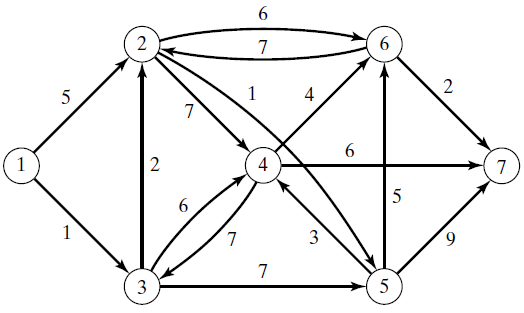

Dado que la figura es una red dirigida, en el caso de cuando hay dos arcos que conectan dos nodos pero de direcciones opuestas (como lo es el nodo), de igual manera omitiremos el arco que va del nodo **$2$** al nodo **$5$** por cuestiones didácticas.

Lo primero que se tiene que hacer es escoger un nodo cualquiera desde el cual empezar;
- <font color="royalblue"> **Paso 0.** </font>
  
  Iteración <font color="paleturquoise">$k=0$ </font>
  Nosotros escogeremos el nodo **1** para empezar entonces, tendremos:
  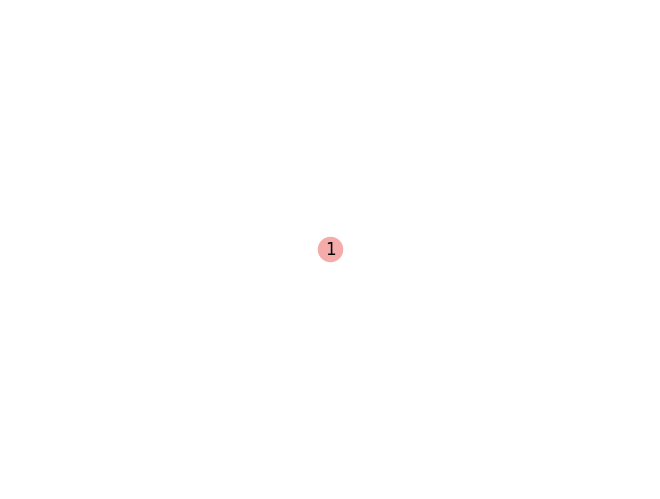


- <font color="royalblue"> **Paso 1.** </font>

  Iteración <font color="paleturquoise">$k=1$ </font>
  
  
  Ahora tendremos lo siguiente, dado que escogimos el nodo **$1$** entonces escogeremos el siguiente nodo más cercano que, en este caso, será el **$3$** dado que la distancia hacia el nodo **$3$** es de $1$ unidad comparado con el nodo **$2$** el cual tiene una distancia de $5$ unidades. Por lo tanto tendremos lo siguiente


  $C_1=\{1, 3\}$ , $\overline{C}_1=\{2, 4, 5\}$
  
  Lo que nos dará la siguiente gráfica:


  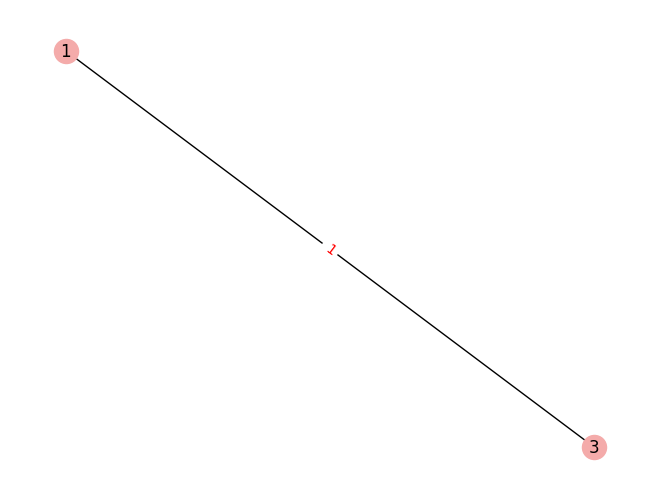


  La cual contará con una distancia total de **$1$**


Ahora hay que repetir el paso hasta cubrir todos los nodos de la red, para ello pasaremos a la iteración <font color="paleturquoise">$k=2$ </font>
- <font color="royalblue"> **Paso 2.** </font>

Ahora tendremos

 $C_1=\{1, 3, 2\}$ , $\overline{C}_1=\{4, 5, 6\}$

 Que nos dará la siguiente gráfica;

 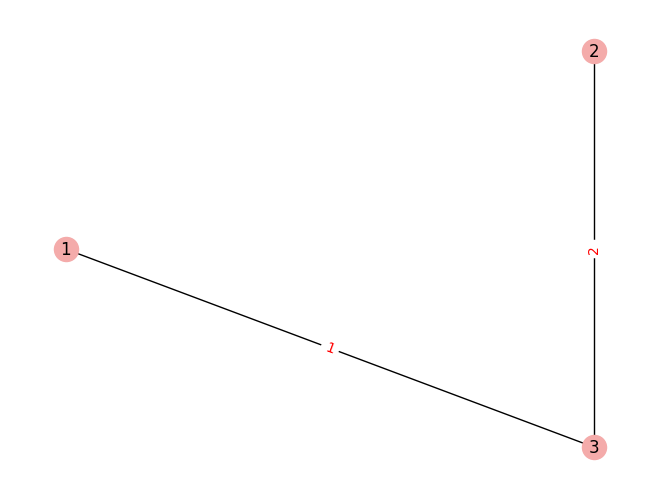


 La cuál tendrá como distancia total **$3$**

Repitiendo sucesivamente las iteraciones llegaremos a lo siguiente ;


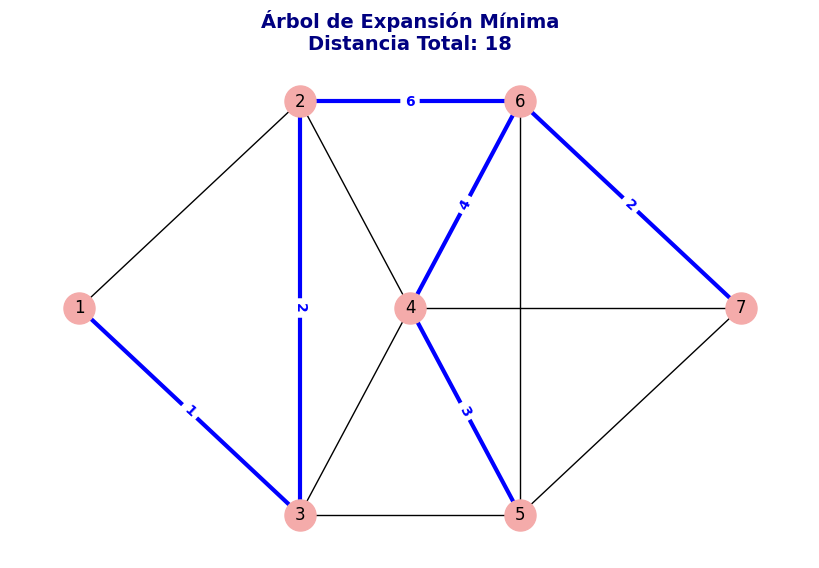

La cuál nos indica cual es la mejor ruta que requiere la menor cantidad de unidades para pasar por todos los nodos.

Una vez entendiendo cómo funciona el método podemos ver el como escribir el código para resolver este tipo de ejercicios por el método de Arbol de Expansión Mínima.

Es importante saber que usaremos la librería de <font color="mediumorchid">NetworkX</font> para las redes y el cómo se trabajen, mientras que usaremos la librería <font color="mediumorchid">Matplotlib</font>. Sabiendo eso podemos continuar.

Lo primero que tenemos que hacer es usar importar las bibliotecas <font color="slateblue"> networkx </font> & <font color="slateblue"> matplotlib.pyplot </font> posteriormente empezaremos con el comando <font color="slateblue"> G = nx.Graph() </font> la cual genera una gráfica vacía sin nodos ni arcos.

Posteriormente usaremos el comando <font color="slateblue"> G.add_weighted_edges_from([]) </font> el cuál nos permite añadir nodos conectados ya asignandoles un valor de "peso" a los arcos, el comando funciona de tal forma:

G.add_weighted_edges_from <font color="yellow">(</font><font color="mediumorchid">[</font>

 <font color="slateblue">(</font><font color="greenmint">nodo$_1$, nodo$_2$, peso</font><font color="slateblue">)</font>,

$...$

 <font color="slateblue">(</font><font color="greenmint">nodo$_i$, nodo$_j$, peso</font><font color="slateblue">)</font>

<font color="mediumorchid">]</font><font color="yellow">)</font>

Una vez añadidos los nodos y los arcos con sus respectivos pesos podemos asignar posiciones específicas para los nodos pero no es necesario para el método.

Ahora hay que llevar un conteo de los pesos que vayamos acumulando, esto se hará con el comando:

peso = nx.get_edge_attributes<font color="yellow">(</font>G, <font color="orange">'weight'</font><font color="yellow">)</font>

Lo que hace es ir tomando en cuenta los atributos de los arcos de la gráfica G

Posteriormente usaremos el comando

T = nx.minimum_spanning_tree<font color="yellow">(</font>G, weight= <font color="orange">'weight'</font><font color="yellow">)</font>

El cuál es el comando que estaremos usando para resolver la gráfica por el método de Arbol de Expansión Mínima. Si ahora iniciamos un contador del peso total acumulado entonces usaremos un ciclo <font color="mediumorchid">for</font> de la siguiente manera:

<font color="mediumorchid">for</font> u, v, data <font color="slateblue">in</font> T.edges<font color="yellow">(</font>data=<font color="slateblue">True</font><font color="yellow">)</font>:

<font color="lemonchiffon">print</font><font color="yellow">(</font><font color="slateblue">f</font><font color="orange">"Arco (</font><font color="mediumorchid">{</font>u<font color="mediumorchid">}</font> <font color="orange">-</font> <font color="mediumorchid">{</font>v<font color="mediumorchid">}</font><font color="orange">) con distancia:</font> <font color="mediumorchid">{</font>data<font color="slateblue">[</font><font color="orange">'weight'</font><font color="slateblue">]</font><font color="mediumorchid">}</font><font color="orange">"</font><font color="yellow">)</font>
distancia_total += data<font color="yellow">[</font><font color="orange">'weight'</font><font color="yellow">]</font>

Así podemos ir acumulando los pesos y al final saber cuánto será el peso de la ruta óptima.

Ahora bien, podemos añadir más comandos para que nos vaya mostrando cosas en la gráfica o en la terminal para correr el programa, sin embargo omimtiremos ese tipo de datos ya que no es algo exclusivo del tema.

Ahora para poder dibujar y mostrar la gráfica usaremos los siguientes comandos:

nx.draw<font color="yellow">(</font>G,...<font color="yellow">)</font>

Dentro de los paréntesis podemos agregar detalles que queremos se muestren en la gráfica

También usaremos;

nx.draw_networkx_edges<font color="yellow">(</font>T,...<font color="yellow">)</font> **Para remarcar únicamente la ruta óptima**

Una vez hecho eso se puede saltar directamente al final del código para mostrar la gráfica o añadir más detalles para poder tener una gráfica más detallada visualmente.

A continuación usaremos el ejemplo hecho anteriormente para resolverlo a través de un código;

Arcos del Árbol de Expansión Mínima:
Arco (1 - 3) con distancia: 1
Arco (2 - 3) con distancia: 2
Arco (2 - 6) con distancia: 6
Arco (6 - 7) con distancia: 2
Arco (6 - 4) con distancia: 4
Arco (4 - 5) con distancia: 3

Distancia total del Árbol de Expansión Mínima: 18


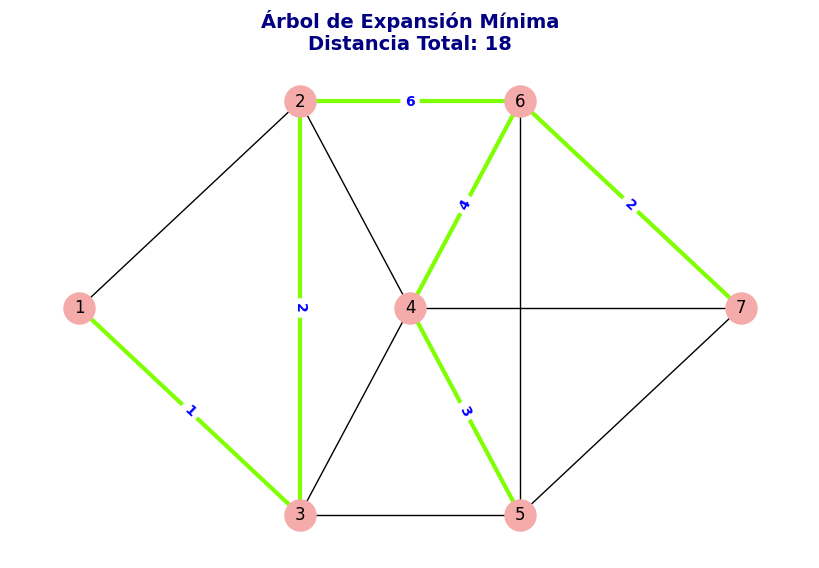

In [30]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()
G.add_weighted_edges_from([
    (1, 2, 5),
    (1, 3, 1),
    (2, 6, 6),
    (2, 4, 7),
    (2, 3, 2),
    (3, 4, 6),
    (3, 5, 7),
    (4, 5, 3),
    (4, 6, 4),
    (4, 7, 6),
    (5, 6, 5),
    (5, 7, 9),
    (6, 7, 2)
])
posiciones = {
    1: (0, 0.5),
    2: (1, 1),
    3: (1, 0),
    4: (1.5, 0.5),
    5: (2, 0),
    6: (2, 1),
    7: (3, 0.5)
}

distancias = nx.get_edge_attributes(G, 'weight')

T = nx.minimum_spanning_tree(G, weight='weight')
print("Arcos del Árbol de Expansión Mínima:")
distancia_total = 0
for u, v, data in T.edges(data=True):
    print(f"Arco ({u} - {v}) con distancia: {data['weight']}")
    distancia_total += data['weight']

print(f"\nDistancia total del Árbol de Expansión Mínima: {distancia_total}")
plt.figure(figsize=(8, 5))

nx.draw(G, pos=posiciones, with_labels=True, node_color="#F4ABAA", node_size=500, width=1)

nx.draw_networkx_edges(T, pos=posiciones, edge_color="chartreuse", width=3)

distancias_AEM = nx.get_edge_attributes(T, 'weight')
nx.draw_networkx_edge_labels(T, pos=posiciones, edge_labels=distancias_AEM, font_color="blue", font_weight="bold")

plt.title(f"Árbol de Expansión Mínima\nDistancia Total: {distancia_total}", fontsize=14, fontweight='bold', color='navy')

plt.savefig('ArboldeExpansionResuelto.png', bbox_inches='tight', dpi=100)
plt.show()

Como se puede ver, se aplicaron los comandos que se mencionaron y se añadieron algunos detalles más para que la gráfica tuviera un mejor diseño en general, sin embargo los comandos relevantes son los ya mencionados.

# **Ruta más corta**

Veamos ahora el problema de la ruta más corta. Considere una red convexa con dos nodos especiales, llamados <font color="yellow">origen</font> y <font color="yellow">destino</font>. El objetivo es <font color="lime">encontrar la ruta más corta - la trayectoria de mínima distancia total - del origen al destino</font>.

La forma en la que funciona el algoritmo es la siguiente:

- <font color="royalblue">**Objetivo de la $n$-ésima iteración** </font>

Encontrar el
$n$-ésimo nodo más cercano al origen. Repetir para $n=1,2,..$ hasta que el $n$-ésimo nodo más cercano sea el destino.

- <font color="royalblue">**Datos de la $n$-ésima iteración** </font>

$n-1$ nodos más cercanos al origen <font color="brown">- encontrados en iteraciones previas -</font>, incluída su ruta más cercana y la distancia al orígen <font color="darkseagreen">(Estos son <font color="yellow">nodos resueltos</font>, el resto son <font color="yellow">nodos no resueltos</font>)</font>.

- <font color="royalblue">Candidato del $n$-ésimo nodo más cercano</font>

Cada nodo <font color="lime"> no resuelto</font> con conexión directa a uno o más nodos resueltos. Se debe tomar el nodo no resuelto que tenga el arco más corto <font color="darkseagreen">(Los empates proporcionan candidatos adicionales)</font>.

Para dar un ejemplo usemos la misma red usada anteriormente con la única diferencia de que ya estamos <font color="lime">tratando a los arcos como distancias</font> y nos referiremos a ellas como tal, aparte de eso ahora si tomaremos en cuenta la red dirigida tal y como se muestra en la imágen.

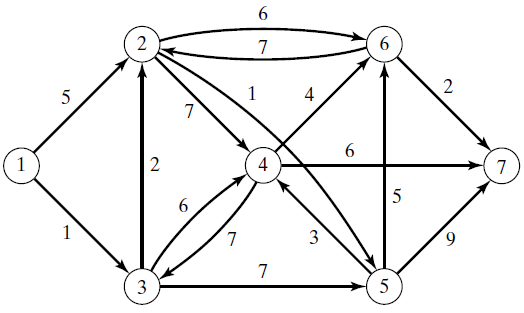

Tomemos al nodo $1$ como el <font color="yellow"> origen</font> y al nodo $7$ como el <font color="yellow"> destino </font> Lo primero que haremos es generar un tabla de la siguiente manera para que podamos llevar registro de lo que hacemos y cómo lo hacemos.
<font color="cyan">
| <center>$n$</center> | <center>Nodos resueltos conectados directamente a nodos no resueltos</center> | <center>Nodo no resuelto más cercano no conectado</center> | <center>Distancia total involucrada</center> | <center>$n$-ésimo nodo más cercano</center> | <center>Distancia Mínima</center> | <center>Última conexión</center> |
|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| <center>$1$</center> | <center>Nodo $1$</center> | <center>Nodo $3$</center> | <center>$1$</center> | <center>Nodo $3$</center> | <center>$1$</center> | <center>Nodo $1$ - Nodo $3$</center> |
| <center>$2$</center> | <center>Nodo $1$, <font color="magenta">Nodo $3$</font></center>| <center>Nodo $2$, <font color="magenta">Nodo $2$</font></center> | <center>$1+2=3$, <font color="magenta">$5$</font></center> | <center>Nodo $2$</center> | <center>$3$</center> | <center>Nodo $3$ - Nodo $2$</center> |
|<center>$3$</center>| <center>Nodo $2$, <font color="magenta">Nodo $3$</font></center> | <center>Nodo $5$, <font color="magenta">Nodo $4$</font></center> | <center>$3+1=4$, <font color="magenta">$1+6=7$</font></center> | <center>Nodo 5</center> | <center>$4$</center> | <center>Nodo $2$ - Nodo $5$</center> |
| <center>$4$</center> | <center>Nodo $2$, <font color="magenta"> Nodo $3$</font>, <font color="lime"> Nodo $5$</font></center> | <center>Nodo $6$, <font color="magenta">Nodo $4$</font>, <font color="lime">Nodo 4</font> </center> | $3+6=9$, <font color="magenta">$1+6=7$</font>, <font color="lime">$4+3=8$ | <center>Nodo $4$</center> | <center>$7$</center> | <center>Nodo $3$ - Nodo $4$</center> |
| <center>$5$</center> | <center>Nodo $2$, <font color="magenta"> Nodo $4$</font>, <font color="lime"> Nodo $5$</font></center> | <center>Nodo $6$, <font color="magenta"> Nodo $6$</font>, <font color="lime">Nodo $6$</font></center> | <center>$3+6=9$, <font color="magenta">$7+4=11$</font>, <font color="lime">$4+5=9$</font></center> | <center>Nodo $6$, <font color="lime"> Nodo $6$</font></center> | <center>$9$</center> | Nodo $2$ - Nodo $6$, <font color="lime"> Nodo $5$ - Nodo $6$</font> |
| <center>$6$</center> | <center>Nodo $4$, <font color="magenta"> Nodo $5$</font>, <font color="lime"> Nodo $6$</font></center> | <center>Nodo $7$, <font color="magenta"> Nodo $7$</font>, <font color="lime"> Nodo $7$</font></center> | <center>$4+9=13$, <font color="magenta">$7+6=13$</font>, <font color="lime">$9+2=11$</font></center> | <center> Nodo $7$</center> | <center>$11$</center> | <center>Nodo $6$ - Nodo $7$</center> |

</font>

Una vez que hemos alcanzado nuestro <font color="yellow">destino</font> entonces podemos marcar nuestra ruta

<font color="brown"> Es importante mencionar que en la iteración $5$ tuvimos dos diferentes rutas que, aunque la distancia involucrada era la misma, conectaban diferentes nodos. Esto es completamente normal ya que nos dice que hay distintas rutas que pueden funcionar cuando se trata de encontrar la distancia mínima como lo fue en este caso </font>

Ahora bien, para marcar nuestra ruta nosotros empezaremos desde nuestro <font color="yellow"> destino </font> hasta nuestro <font color="yellow"> origen </font> para escribir la solución de la siguiente manera:

Para no repetir la palabra "Nodo" únicamente escribiremos el número del nodo pero se entiende que hablamos del Nodo $i$-ésimo

- <font color="RoyalBlue">Solución 1</font>
<font color="greenyellow">
  $7 \rightarrow 6 \rightarrow 2 \rightarrow 3 \rightarrow 1$
</font>

  y su ruta pasa a ser;

<font color="greenyellow">
  $1 \rightarrow 3 \rightarrow 2 \rightarrow 6 \rightarrow 7$
</font>

  con distancia total de <font color="greenyellow">**$11$**</font>

- <font color="royalblue">Solución 2</font>
<font color="greenyellow">
  $7 \rightarrow 6 \rightarrow 5 \rightarrow 2 \rightarrow 3 \rightarrow 1$
</font>

  y su ruta pasa a ser;

<font color="greenyellow">
  $1 \rightarrow 3 \rightarrow 2 \rightarrow 5 \rightarrow 6 \rightarrow 7$
  </font>

  con distancia total de <font color="greenyellow">**$11$**

  Ahora que sabemos cómo funciona el algoritmo podemos pasar a ver como funciona y como se aplica en código de la siguiente manera:

  Lo primero es importar las librerias, posterior a eso usaremos el comando

  <font  color="turquoise">G_dirigida = nx.DiGraph()</font>
  
  Este nos permite crear una gráfica dirigida vacía.

  Igual añadiremos arcos con pesos y, es importante saber que, les añadiremos los pesos correspondientes en las direcciones correspondientes, es decir, si tenemos dos nodos $A$ y $B$ unidos entre ellos entonces podemos decir que el arco que va del nodo $A$ al nodo $B$ tiene una distancia de 5 pero la distancia del nodo $B$ al $A$ es 7, entonces podemos expresarlo en código como

  <font color="turquoise"> ($A$,$B$,$5$)</font> & <font color="turquoise"> ($B$,$A$,$7$) </font>

  Una vez notada la diferencia podemos crear este tipo de arcos con un peso asignado usando el comando:

  <FONT COLOR="turquoise"> G_dirigida.add_weighted_edges_from([ $...$ ])

  Agregamos dos variables las cuales nos indiquen el <font color="yellow"> origen </font> y el <font color="yellow"> destino </font>.

  Ahora, dado que hay varias rutas vamos a generar una lista donde se encuentren todas las rutas de la siguiente manera:

<font color="turquoise"> todas_las_rutas = list(nx.all_shortest_paths(G_dirigido, source=origen, target=destino, weight='weight'))

</font>

Y conseguiremos la ruta más corta de la siguiente manera:

<font color="turquoise"> distancia_minima = nx.shortest_path_length(G_dirigido, source=origen, target=destino, weight='weight')  </font>

Se pueden añadir más comandos para mejorar visualmente la gráfica o imprimir únicamente la ruta más corta pero se llegará a algo como lo siguiente:

Resultados de la Ruta Más Corta
Distancia mínima del nodo 1 al nodo 7: 11

Solución 1: 1 -> 3 -> 2 -> 6 -> 7
Solución 2: 1 -> 3 -> 2 -> 5 -> 6 -> 7


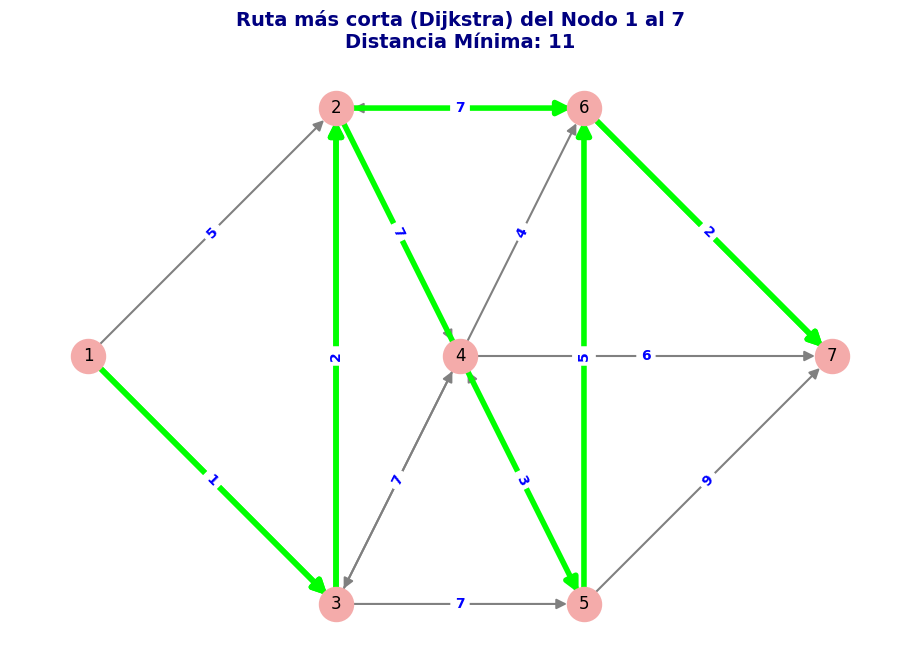

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

G_dirigida = nx.DiGraph()
G_dirigida.add_weighted_edges_from([
    (1, 2, 5),
    (1, 3, 1),
    (2, 6, 6),
    (2, 4, 7),
    (3, 2, 2),
    (3, 4, 6),
    (3, 5, 7),
    (4, 6, 4),
    (4, 7, 6),
    (4, 3, 7),
    (5, 4, 3),
    (5, 6, 5),
    (5, 7, 9),
    (6, 2, 7),
    (6, 7, 2),
    (2, 5, 1),
])

posiciones = {
    1: (0, 0.5),
    2: (1, 1),
    3: (1, 0),
    4: (1.5, 0.5),
    5: (2, 0),
    6: (2, 1),
    7: (3, 0.5)
}

origen = 1
destino = 7

todas_las_rutas = list(nx.all_shortest_paths(G_dirigida, source=origen, target=destino, weight='weight'))
distancia_minima = nx.shortest_path_length(G_dirigida, source=origen, target=destino, weight='weight')

print("Resultados de la Ruta Más Corta")
print(f"Distancia mínima del nodo {origen} al nodo {destino}: {distancia_minima}\n")
for i, ruta in enumerate(todas_las_rutas, 1):
    ruta_formateada = " -> ".join(map(str, ruta))
    print(f"Solución {i}: {ruta_formateada}")

plt.figure(figsize=(9, 6))

nx.draw(G_dirigida, pos=posiciones, with_labels=True, node_color="#F4ABAA", node_size=600, width=1.5, edge_color="gray", arrowsize=15)

aristas_ruta = []
for ruta in todas_las_rutas:
    for u, v in zip(ruta[:-1], ruta[1:]):
        aristas_ruta.append((u, v))

nx.draw_networkx_edges(G_dirigida, pos=posiciones, edgelist=aristas_ruta, edge_color="lime", width=4, arrowsize=20)

etiquetas_aristas = nx.get_edge_attributes(G_dirigida, 'weight')
nx.draw_networkx_edge_labels(G_dirigida, pos=posiciones, edge_labels=etiquetas_aristas, font_color="blue", font_weight="bold")

plt.title(f"Ruta más corta (Dijkstra) del Nodo {origen} al {destino}\nDistancia Mínima: {distancia_minima}", fontsize=14, fontweight='bold', color='navy')

plt.savefig('RutaMasCortaResuelta.png', bbox_inches='tight', dpi=100)
plt.show()

# **Flujo Máximo**

El problema de Flujo Máximo busca <font color="lime">determinar la mayor cantidad de flujo que puede transitar a través de un sistema interconectado</font> <font color="red">sin exceder la capacidad de los enlaces</font>.

Todo el flujo se origina en un único nodo inicial llamado <font color="yellow">fuente</font> y debeterminar en su totalidad en un nodo de destino conocido como <font color="yellow">sumidero</font>, <font color="red">conservando estrictamente el equilibrio en los puntos intermedios</font>. Para resolverlo el algoritmo itera una red de flujos, la cual ilustra las <font color="darkseagreen">capacidades</font> de los nodos y permite redirigir flujos en direcciones opuestas si esto optimiza el total de la red. La condición de <font color="darkseagreen">parada</font> depende del teorema de flujo máximo-corte mínimo, el cual dice que el <font color="lime">flujo total máximo está estrictamente limitado por el nodo con menor capacidad de flujo que se encuentre en la red</font>.

Veamos ahora un ejemplo con el siguiente ejercicio:

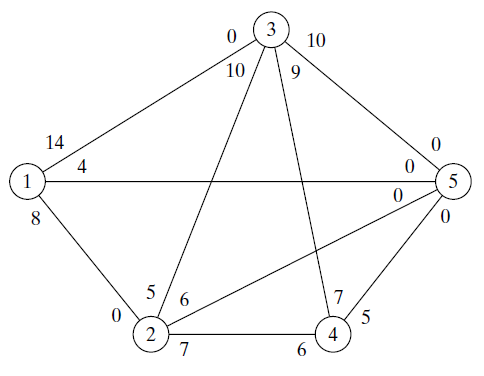

- <font color="RoyalBlue"> Iteración $1$</font>

Lo primero que tenemos que hacer es ubicar nuestro nodo <font color="yellow"> fuente</font>, en este caso será el nodo $1$, ahora nos iremos al nodo que requiera la menor cantidad de flujo, en este caso es el nodo $5$ que requiere un flujo máximo de <font color="lime"> **$4$**</font>.

**$1$**$\rightarrow$**$5$** y entonces va a cambiar el flujo disponible tal y como se ve en la siguiente imágen.

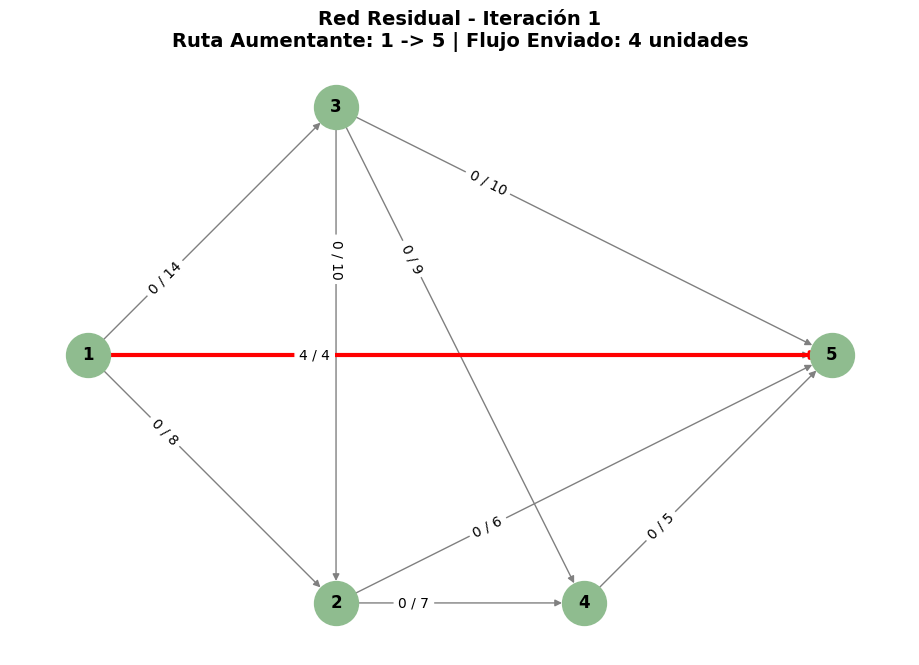


- <font color="royalblue"> Iteración 2</font>

Ahora bien, vemos que la siguiente conexión que podemos hacer es:

$1 \rightarrow 3 \rightarrow 5$
que va a tener como flujo máximo <font color="lime">$10$</font>. Esto lo podemos ver en la siguiente gráfica:

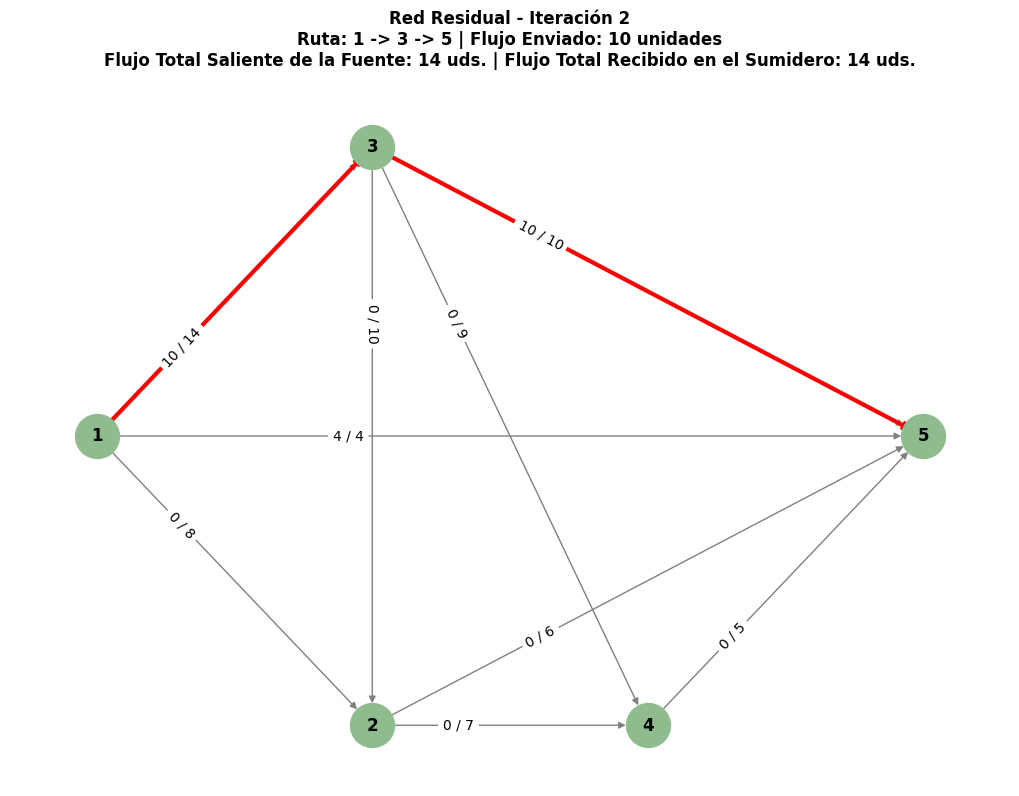

- <font color="royalblue"> Iteración 3</font>

Ahora tomaremos la ruta de:

$1 \rightarrow 2 \rightarrow 5$ que va a tener un flujo máximo de <font color="lime">6</font>. Lo cuál se puede ver en la siguiente gráfica:

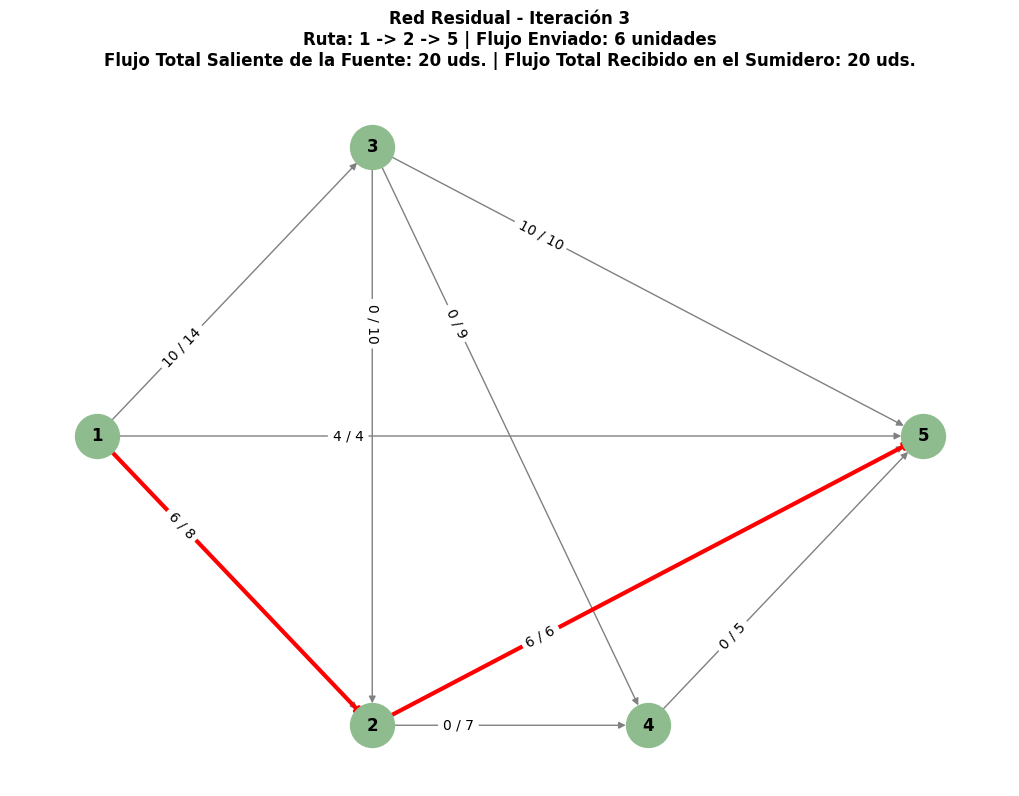

  Y así podemos continuar hasta llegar a la última gráfica y la última ruta la cuál será:

  $1 \rightarrow 3 \rightarrow 4 \rightarrow 5$ con flujo máximo de <font color="lime">$3$</font>.

  La gráfica final será:

  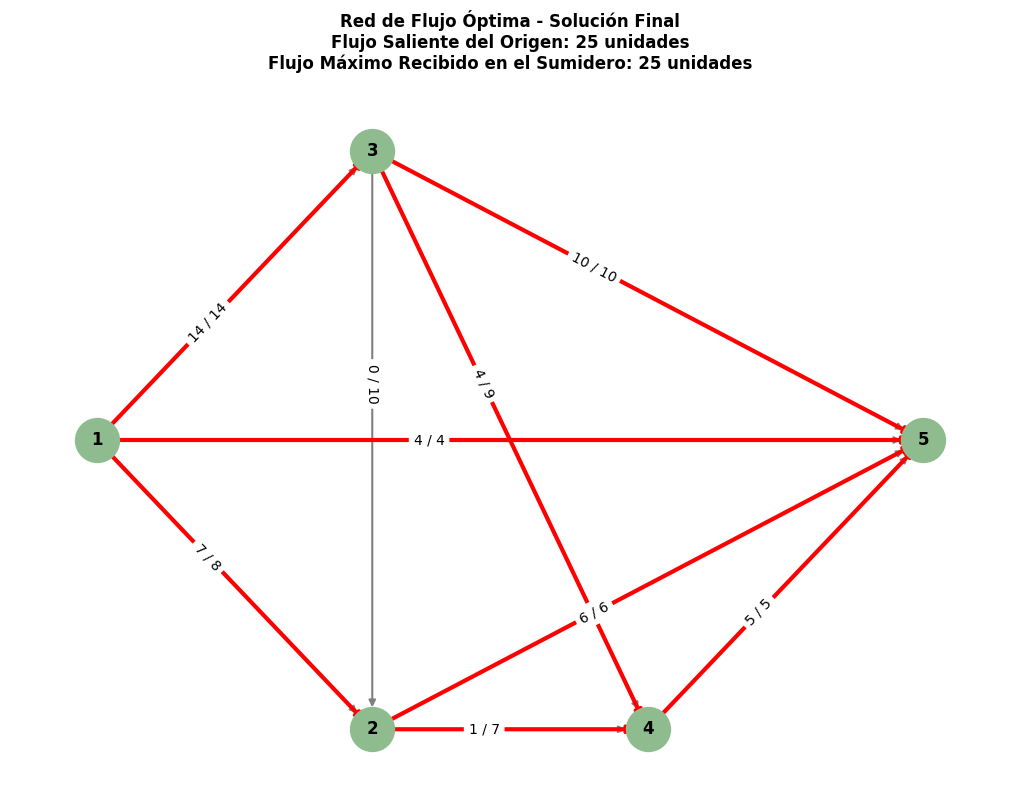

Ahora veamos cómo se puede programar el problema para, de esta forma, poder resolverlo de manera computacional.

Lo primero es importar las librerías, una vez hecho eso vamos a definir una función que resuelva el problema. Usando el comando para generar una gráfica dirigida vacía y datos de la red tal y como lo es el nombre de los nodos, la conexión dirigida y el peso de los mismos. Una vez hecho eso vamos a añadir arcos y, si queremos, podemos añadir posiciones específicas a los nodos.  De igual manera hay que definir las variables <font color="yellow"> fuente</font> y <font color="yellow">sumidero</font>.

Ahora bien, usaremos el comando

<font color="turquoise">valor_flujo_maximo, almacen_flujos = nx.maximum_flow(G, fuente, sumidero)</font>

Para poder ir guardando valores y calcular el flujo máximo de la gráfica ya definida entre la fuente y el sumidero

Podemos ir guardando los flujos y añadir más detalles para la gráfica pero eso es únicamente visual, no afecta a la resolución final.

Una vez resuelto tendremos un codigo similar al siguiente:



Resultados del Flujo Máximo
Flujo Máximo Total de 1 a 5: 25 unidades
Flujo Total Saliente del Origen (Nodo 1): 25 unidades

Flujo enviado por cada arco:
Arco (1 -> 2) | Flujo: 7 / Capacidad: 8
Arco (1 -> 3) | Flujo: 14 / Capacidad: 14
Arco (1 -> 5) | Flujo: 4 / Capacidad: 4
Arco (2 -> 4) | Flujo: 1 / Capacidad: 7
Arco (2 -> 5) | Flujo: 6 / Capacidad: 6
Arco (3 -> 2) | Flujo: 0 / Capacidad: 10
Arco (3 -> 4) | Flujo: 4 / Capacidad: 9
Arco (3 -> 5) | Flujo: 10 / Capacidad: 10
Arco (4 -> 5) | Flujo: 5 / Capacidad: 5


/tmp/ipykernel_3439/602652296.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


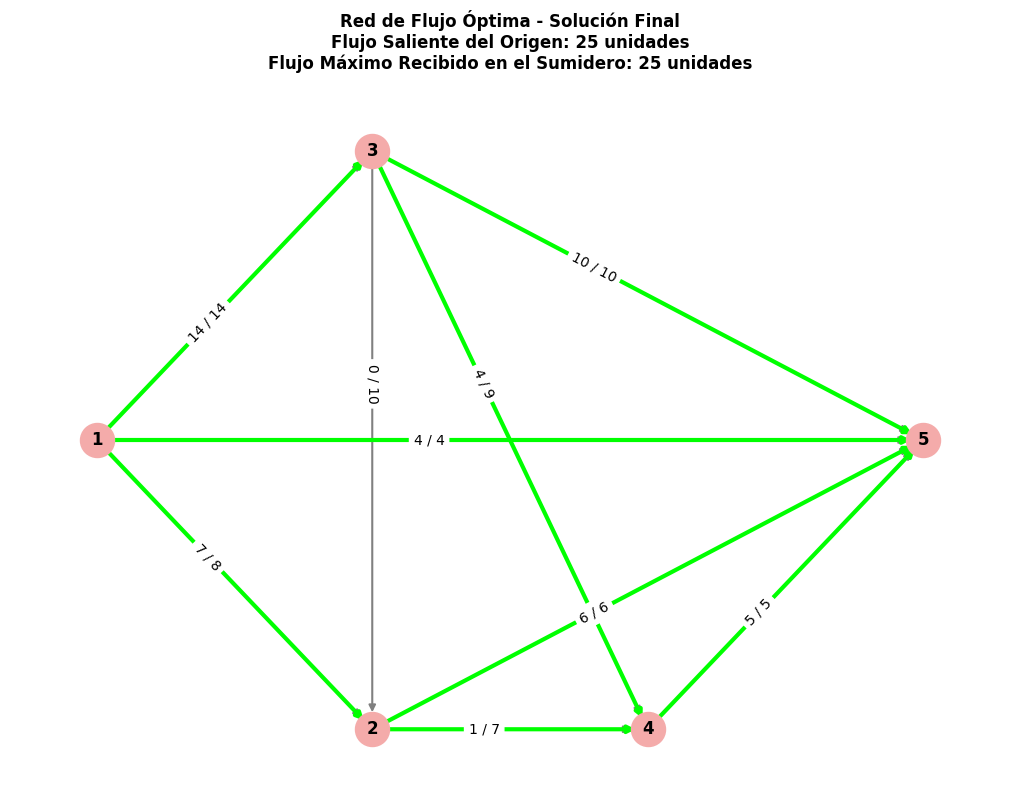

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

def resolver_flujo_maximo():
    G = nx.DiGraph()

    datos_red = [
        (1, 2, 8),
        (1, 3, 14),
        (1, 5, 4),
        (3, 2, 10),
        (3, 4, 9),
        (3, 5, 10),
        (2, 4, 7),
        (2, 5, 6),
        (4, 5, 5)
    ]

    for origen, destino, capacidad in datos_red:
        G.add_edge(origen, destino, capacity=capacidad)

    posiciones = {
        1: (0, 1),
        2: (1, 0),
        3: (1, 2),
        4: (2, 0),
        5: (3, 1)
    }

    fuente = 1
    sumidero = 5

    valor_flujo_maximo, almacen_flujos = nx.maximum_flow(G, fuente, sumidero)

    for u, vecinos in almacen_flujos.items():
        for v, flujo in vecinos.items():
            if G.has_edge(u, v):
                G[u][v]['flow'] = flujo

    flujo_saliente_total = sum(G[fuente][v]['flow'] for v in G.neighbors(fuente))

    print("Resultados del Flujo Máximo")
    print(f"Flujo Máximo Total de {fuente} a {sumidero}: {valor_flujo_maximo} unidades")
    print(f"Flujo Total Saliente del Origen (Nodo {fuente}): {flujo_saliente_total} unidades\n")
    print("Flujo enviado por cada arco:")
    for u, vecinos in almacen_flujos.items():
        for v, flujo in vecinos.items():
            if G.has_edge(u, v):
                capacidad = G[u][v]['capacity']
                print(f"Arco ({u} -> {v}) | Flujo: {flujo} / Capacidad: {capacidad}")

    etiquetas_arcos = {
        (u, v): f"{G[u][v]['flow']} / {G[u][v]['capacity']}"
        for u, v in G.edges()
    }

    plt.figure(figsize=(10, 7))

    nx.draw(G, posiciones, with_labels=True, node_color='#F4ABAA',
            node_size=600, font_size=12, font_weight='bold', arrows=True,
            edge_color='gray', width=1.5)

    aristas_con_flujo = [(u, v) for u, v in G.edges() if G[u][v]['flow'] > 0]
    nx.draw_networkx_edges(G, posiciones, edgelist=aristas_con_flujo, edge_color='lime', width=3.0)

    nx.draw_networkx_edge_labels(G, posiciones, edge_labels=etiquetas_arcos,
                                 font_color='black', font_size=10, label_pos=0.4)

    titulo_texto = (
        f"Red de Flujo Óptima - Solución Final\n"
        f"Flujo Saliente del Origen: {flujo_saliente_total} unidades\n"
        f"Flujo Máximo Recibido en el Sumidero: {valor_flujo_maximo} unidades"
    )
    plt.title(titulo_texto, fontsize=12, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('FlujoMaximoResuelto.png', bbox_inches='tight', dpi=100)
    plt.show()

if __name__ == "__main__":
    resolver_flujo_maximo()